In [1]:
import requests
import json
import datetime
import pandas as pd

from evidently import ColumnMapping
from evidently.report import Report
from evidently.metrics import ColumnDriftMetric, DatasetDriftMetric, DatasetMissingValuesMetric, ColumnQuantileMetric

from joblib import load, dump
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [29]:
files = [('green_tripdata_2024-03.parquet', './data')]

print("Download files:")
for file, path in files:
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    resp = requests.get(url, stream=True)
    save_path = f"{path}/{file}"
    with open(save_path, "wb") as handle:
        for data in tqdm(resp.iter_content(),
                         desc=f"{file}",
                         postfix=f"save to {save_path}",
                         total=int(resp.headers["Content-Length"])):
            handle.write(data)

Download files:


green_tripdata_2024-03.parquet: 100%|██████████| 1372372/1372372 [00:03<00:00, 376577.95it/s, save to ./data/green_tripdata_2024-03.parquet]


In [2]:
march_data = pd.read_parquet('data/green_tripdata_2024-03.parquet')
march_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,57457.000000,57457,57457,55360.000000,57457.000000,57457.000000,55360.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,0.0,57457.000000,57457.000000,55360.000000,55353.000000,55360.000000
mean,1.877334,2024-03-16 04:02:52.405399,2024-03-16 04:21:00.076039,1.179986,95.524688,138.629149,1.309538,13.522828,17.313474,0.904472,0.577410,2.386255,0.192537,NaN,0.979378,22.904832,1.321062,1.038047,0.737730
min,1.000000,2008-12-31 23:02:24,2008-12-31 23:02:30,1.000000,1.000000,1.000000,0.000000,0.000000,-295.080000,-2.500000,-0.500000,-1.560000,0.000000,NaN,-1.000000,-296.080000,1.000000,1.000000,-2.750000
25%,2.000000,2024-03-08 13:53:56,2024-03-08 14:13:49,1.000000,74.000000,74.000000,1.000000,1.100000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,13.440000,1.000000,1.000000,0.000000
50%,2.000000,2024-03-15 22:49:01,2024-03-15 23:09:52,1.000000,75.000000,138.000000,1.000000,1.790000,13.500000,0.000000,0.500000,2.000000,0.000000,NaN,1.000000,18.500000,1.000000,1.000000,0.000000
75%,2.000000,2024-03-23 20:11:25,2024-03-23 20:34:48,1.000000,97.000000,220.000000,1.000000,3.100000,19.800000,1.000000,0.500000,3.610000,0.000000,NaN,1.000000,27.050000,2.000000,1.000000,2.750000
max,2.000000,2024-04-01 00:01:45,2024-04-01 16:11:00,99.000000,265.000000,265.000000,9.000000,125112.200000,841.600000,10.000000,4.250000,150.000000,26.760000,NaN,1.000000,856.980000,5.000000,2.000000,2.750000
std,0.328056,NaN,NaN,1.356719,57.285088,76.295346,0.967749,770.416255,14.958249,1.382446,0.366916,3.159273,1.184551,NaN,0.154253,17.013735,0.497858,0.191311,1.218039


In [22]:
march_data


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration_min
0,2,2024-03-01 00:10:52,2024-03-01 00:26:12,N,1.0,129,226,1.0,1.72,12.8,...,0.5,3.06,0.0,NaN,1.0,18.36,1.0,1.0,0.00,15.333333
1,2,2024-03-01 00:22:21,2024-03-01 00:35:15,N,1.0,130,218,1.0,3.25,17.7,...,0.5,0.00,0.0,NaN,1.0,20.20,2.0,1.0,0.00,12.900000
2,2,2024-03-01 00:45:27,2024-03-01 01:04:32,N,1.0,255,107,2.0,4.58,23.3,...,0.5,3.50,0.0,NaN,1.0,32.05,1.0,1.0,2.75,19.083333
3,1,2024-03-01 00:02:00,2024-03-01 00:23:45,N,1.0,181,71,1.0,0.00,22.5,...,1.5,0.00,0.0,NaN,1.0,24.00,1.0,1.0,0.00,21.750000
4,2,2024-03-01 00:16:45,2024-03-01 00:23:25,N,1.0,95,135,1.0,1.15,8.6,...,0.5,1.00,0.0,NaN,1.0,12.10,1.0,1.0,0.00,6.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55355,2,2024-03-31 23:22:56,2024-03-31 23:25:37,N,1.0,41,41,1.0,0.62,5.1,...,0.5,0.00,0.0,NaN,1.0,7.60,2.0,1.0,0.00,2.683333
55356,2,2024-03-31 23:42:52,2024-03-31 23:52:46,N,1.0,95,56,1.0,1.54,11.4,...,0.5,2.78,0.0,NaN,1.0,16.68,1.0,1.0,0.00,9.900000
55357,2,2024-03-31 23:28:58,2024-03-31 23:43:42,N,1.0,74,151,1.0,1.90,13.5,...,0.5,4.00,0.0,NaN,1.0,20.00,1.0,1.0,0.00,14.733333
55358,2,2024-03-31 23:36:25,2024-03-31 23:49:22,N,1.0,74,244,1.0,3.64,19.1,...,0.5,0.00,0.0,NaN,1.0,21.60,2.0,1.0,0.00,12.950000


In [3]:
# Q1 
march_data.shape

(57457, 20)

In [4]:
# create target
march_data["duration_min"] = march_data.lpep_dropoff_datetime - \
    march_data.lpep_pickup_datetime
march_data.duration_min = march_data.duration_min.apply(
    lambda td: float(td.total_seconds())/60)

In [5]:
# filter out outliers
march_data = march_data[(march_data.duration_min >= 0) &
                    (march_data.duration_min <= 60)]
march_data = march_data[(march_data.passenger_count > 0) &
                    (march_data.passenger_count <= 8)]

<Axes: >

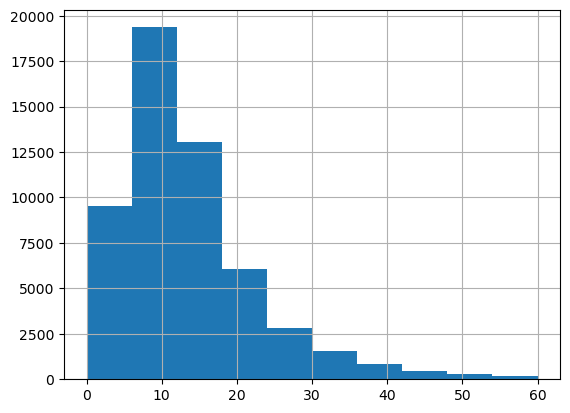

In [6]:
march_data.duration_min.hist()

In [7]:
# data labeling
target = "duration_min"
num_features = ["passenger_count",
                "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [8]:
march_data.shape

(54135, 21)

In [9]:
train_data = march_data[:30000]
val_data = march_data[30000:]

In [10]:
model = LinearRegression()

In [12]:
model.fit(train_data[num_features + cat_features], train_data[target])

LinearRegression()

In [13]:
train_preds = model.predict(train_data[num_features + cat_features])
train_data['prediction'] = train_preds

In [14]:
val_preds = model.predict(val_data[num_features + cat_features])
val_data['prediction'] = val_preds

In [15]:
print(mean_absolute_error(train_data.duration_min, train_data.prediction))
print(mean_absolute_error(val_data.duration_min, val_data.prediction))

3.7724732393594484
3.71681456792937


In [16]:
# Dump model and reference data
with open('models/lin_reg.bin', 'wb') as f_out:
    dump(model, f_out)


In [17]:
val_data.to_parquet('data/reference.parquet')

Evidently Report

In [18]:
column_mapping = ColumnMapping(
    target=None,  # This assumes, we don't have actual values right now at the moment we're loggin the deployed model performance which exacty happens in real word application. This contains the true, actual values that your model is trying to predict
    prediction='prediction', # predicated taxi duration time. This contains the values predicted by your model
    numerical_features=num_features,
    categorical_features=cat_features
)

In [51]:
report = Report(metrics=[
    ColumnDriftMetric(column_name="prediction"),
    DatasetDriftMetric(),
    DatasetMissingValuesMetric(),
    ColumnQuantileMetric(column_name="fare_amount",quantile=0.5),  # Median of fare_amount
    ]
)

In [20]:
report.run(reference_data=train_data, current_data=val_data,
           column_mapping=column_mapping)

In [24]:
result = report.as_dict()

In [ ]:
report.show(mode='inline')

In [38]:
# Q2 What other metric did you choose?
# I chose the prediction drift
prediction_drift = result['metrics'][0]['result']['drift_score']
prediction_drift

0.0100645937800968

In [115]:
# Current_data
reference_data = pd.read_parquet('data/reference.parquet')
daily_data = pd.read_parquet('data/green_tripdata_2024-03.parquet')

daily_data["duration_min"] = daily_data.lpep_dropoff_datetime - \
    daily_data.lpep_pickup_datetime
daily_data.duration_min = daily_data.duration_min.apply(
    lambda td: float(td.total_seconds())/60)

# Initialize an empty list to store daily medians
daily_medians = []

# Iterate over each day in March 2024
for date in pd.date_range(start='2024-03-01', end='2024-03-31'):
    daily_data = march_data[march_data['lpep_pickup_datetime'].dt.date == date.date(
    )]
    if not daily_data.empty:
        if 'duration_min' in daily_data.columns:
            daily_data['prediction'] = daily_data['duration_min']
        else:
            raise ValueError("The 'duration_min' column is missing in the daily data.") 
        report.run(reference_data=reference_data, current_data=daily_data,
                   column_mapping=column_mapping)
        result = report.as_dict()

        # Extract the median value from the report
        median_value = result['metrics'][3]['result']['current']['value']
        daily_medians.append(median_value)

# Q3 Find the maximum median value
max_daily_median = max(daily_medians)
print("The maximum daily median fare amount in March 2024 is:", max_daily_median)

The maximum daily median fare amount in March 2024 is: 14.2
